In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [28]:
features = pd.read_csv("src/data/training/raw/merged_training_data.csv")

In [19]:
features['mix__sd_od_history_to_kyc_ratio'] = features['od__history_length_days'] / features['sd__age_since_first_kyc']

In [21]:
ordinal_features = [
    "cb__worst_score",
    "gender",
    "cb__most_recent_score",
    "sd__membership_product"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__worst_score
        ["MALE", "FEMALE", "NON_BINARY"],                                                                 # gender
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__most_recent_score
        ["PERSONAL_FLEX", "PERSONAL_STANDARD", "PERSONAL_SMART"
         , "PERSONAL_YOU", "PERSONAL_METAL", "BUSINESS_STANDARD"
         , "BUSINESS_SMART", "BUSINESS_YOU", "BUSINESS_METAL", np.nan]        # sd__membership_product
    ],
    encoded_missing_value=np.nan
)

features[ordinal_features] = ordinal_encoder.fit_transform(
    features[ordinal_features]
)

In [22]:
features.head(5)

,user_id,reference_date,default_date,ob__limit_ref,ob__balance_ref,ob__avg_util_ref,ob__open_limit_ref,t__is_drawn,t__ccf,mv__is_lisbon_v1,mv__is_lisbon_v2,mv__is_lisbon_v3,mv__is_lisbon_v4,mv__is_porto_v1,mv__is_porto_v2,ef__is_covid,gender,nationality,sd__age,sd__age_since_first_kyc,sd__age_since_last_kyc,sd__membership_product,sd__max_daily_logins_6m,sd__max_daily_logins_12m,madrid__avg_monthly_salary_3m,madrid__avg_monthly_expenses_3m,madrid__avg_monthly_repayment_capacity_3m,ul__is_expat,od__history_length_days,od__is_history,ob__avg_util_3m,ob__avg_util_change_3m,ob__max_util_3m,ob__max_util_change_3m,ob__std_util_3m,ob__std_util_change_3m,ob__util_slope_3m,ob__util_range_3m,ob__num_od_entries_6m,ob__num_od_exits_6m,ob__overlimit_days_6m,ob__full_repayment_events_6m,ob__max_consecutive_od_days_since_creation_ratio,ob__od_draw_days_6m,ob__od_enabled_zero_util_days_6m,ob__technical_od_days_6m,ob__technical_od_deep_days_6m,ob__avg_util_first_2m_since_creation,ob__avg_util_change_last2m_to_first2m,ob__avg_util_first2m_1y,ob__avg_util_change_last2m_to_first2m_1y,ob__max_consecutive_overlimit_days_since_creation_ratio,ob__partial_repayment_events_6m,ob__full_repayment_change_3m_vs_prev_3m,ob__util_last2m_to_first2m_ratio,ob__util_last2m_to_first2m_1y_ratio,ob__max_to_avg_util_3m_ratio,ab__avg_bal_3m,ab__avg_bal_change_3m,ab__max_util_3m,ab__max_bal_change_3m,ab__std_util_3m,ab__std_bal_change_3m,ab__bal_changed_3m,ab__bal_change_freq_3m,ab__mean_abs_change_6m,ab__std_abs_change_6m,ab__max_one_day_drop_6m,ab__inflow_spike_count_6m,ab__days_down_6m,ab__near_zero_days_6m,dn__recent_action,dn__max_action_level,cb__most_recent_score,cb__worst_score,ep__cc_tbil_balance,mix__sd_od_history_to_kyc_ratio
0,e71e8a98-7408-4a0a-9ffb-aa634d49e6a9,2023-08-21,2024-08-20,6000.0,5998.78,0.9998,0.0002,1,1.00000,1,0,0,0,0,0,0,0.0,AUT,40,2017.0,2017.0,1.0,30.0,30.0,0.00,0.000000,1169.000000,0,2018,1,1.007732,0.015231,1.029796,0.030621,0.022957,-0.014908,2.739301e-09,0.188728,0,0,56,0,0.0,181,0,0,0,0.739344,0.275498,1.006010,0.008832,0.0,6,0,1.3726,1.0087,1.0218,-6046.395604,-91.389398,-5046.41,-952.37,137.744446,-8.944555e+01,1,4,56.875083,348.784107,-3384.51,3,6,0,1.0,90.0,3.0,3.0,0.0,1.000496
1,e928e2e6-531b-4e23-928e-613c8d622dfd,2024-07-30,2025-07-30,250.0,0.00,0.0000,1.0000,1,0.14040,0,0,0,0,1,0,0,1.0,POL,45,150.0,150.0,1.0,7.0,7.0,0.00,0.000000,10.000000,1,136,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2,2,9,2,0.0,19,117,0,0,0.234047,-0.234047,NaN,NaN,0.0,0,-2,0.0000,NaN,NaN,2.112198,-0.610000,2.32,-0.61,0.290700,4.689331e-16,1,1,17.201000,90.570267,-590.49,3,6,124,10.0,10.0,2.0,2.0,0.0,0.906667
2,eaaee9d7-3aea-4a4c-aaa3-65c2c1b4191f,2022-12-07,2023-12-07,500.0,0.00,0.0000,1.0000,1,1.00000,1,0,0,0,0,0,0,0.0,DEU,27,2224.0,2224.0,2.0,7.0,7.0,0.00,607.000000,1881.333333,0,2225,1,0.163381,-0.479873,0.729000,-0.713720,0.299839,-0.341119,-7.610887e-08,0.729000,3,4,0,4,0.0,46,135,0,0,0.000000,0.006275,0.433903,-0.427628,0.0,1,2,NaN,0.0144,4.4619,232.568022,1059.584624,3492.36,3412.86,904.980947,1.130881e+03,1,20,57.020552,356.241185,-3063.00,5,19,46,NaN,NaN,4.0,4.0,0.0,1.000450
3,ed03a294-1ebb-473b-97e8-5a0abab56b8d,2018-11-27,2019-03-19,250.0,0.00,0.0000,1.0000,0,0.00000,1,0,0,0,0,0,0,0.0,DEU,29,505.0,505.0,5.0,12.0,19.0,10311.25,25706.363333,24658.186667,0,1,1,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,0,0,0,0,NaN,0,1,0,0,0.000000,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1139.883626,656.021624,4717.45,2087.02,1105.999238,7.997399e+02,1,69,529.733204,912.332390,-3813.61,40,84,1,NaN,NaN,6.0,7.0,0.0,0.001980
4,f0560a88-6dbd-4c5c-965d-9c6dc11ab2a0,2022-02-08,2022-02-15,500.0,0.00,0.0000,1.0000,1,0.26204,1,0,0,0,0,0,0,0.0,USA,25,111.0,111.0,1.0,2.0,2.0,0.00,43.046667,88.163333,1,1,1,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,0,0,0,0,NaN,0,1,0,0,0.000000,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,62.708022,75.536720,172.30,121.21,53.587515,5.436521e+01,1,24,6.938919,19.735941,-61.58,0,21,42,NaN,NaN,7.0

In [23]:
feature_groups = ['ab__', 'cb__', 'sd__', 'ep__', 
                  'mv__', 'ob__', 'ul__',  'mix__']

target_cols = ['t__ccf']

UNIVARIATE ANALYSIS - FEATURE GROUP: ab__


######## TARGET: t__ccf (Continuous) ########


Feature: ab__avg_bal_3m
Pearson Corr:  -0.0670
Spearman Corr: -0.1125

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-10285.719000000001, -5884.36]",0.646474,1.00000,1522
"(-5884.36, -3736.721]",0.609339,0.99594,1521
"(-3736.721, -1725.768]",0.619186,0.99951,1521
"(-1725.768, -491.351]",0.619458,0.99580,1521
"(-491.351, -238.991]",0.656311,1.00000,1521
"(-238.991, -27.094]",0.630898,1.00000,1521
"(-27.094, 30.758]",0.579812,0.91282,1521
"(30.758, 211.409]",0.600701,0.88706,1521
"(211.409, 773.699]",0.530316,0.68040,1521


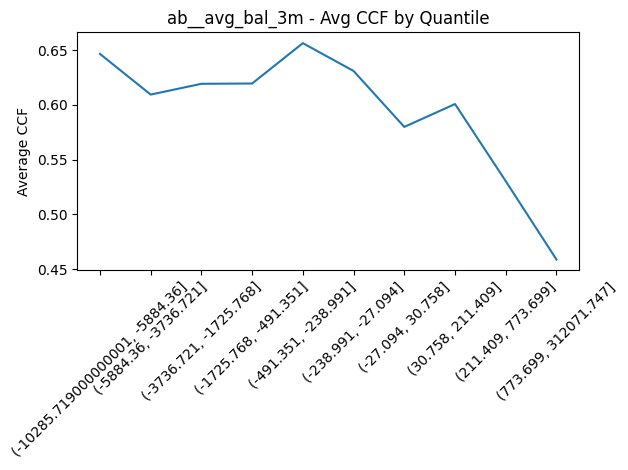


Feature: ab__avg_bal_change_3m
Pearson Corr:  -0.0165
Spearman Corr: 0.0142

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-95513.6, -1068.485]",0.567255,0.790445,1458
"(-1068.485, -350.022]",0.562866,0.804545,1458
"(-350.022, -132.304]",0.551137,0.834790,1458
"(-132.304, -44.86]",0.583189,0.939095,1458
"(-44.86, -9.158]",0.639228,1.000000,1458
"(-9.158, 0.269]",0.645575,1.000000,1458
"(0.269, 42.257]",0.641224,1.000000,1458
"(42.257, 150.211]",0.624793,0.995250,1458
"(150.211, 488.856]",0.575343,0.869735,1458


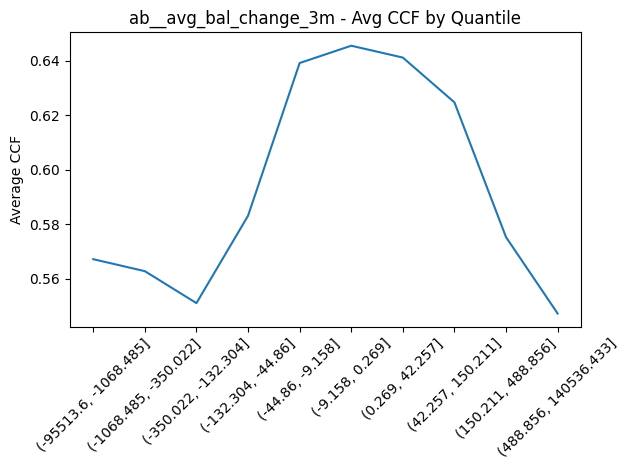


Feature: ab__max_util_3m
Pearson Corr:  -0.0493
Spearman Corr: -0.1302

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-10000.001, -4668.57]",0.658226,1.00000,1522
"(-4668.57, -2131.58]",0.617584,1.00000,1521
"(-2131.58, -487.39]",0.619195,1.00000,1521
"(-487.39, -95.2]",0.697965,1.00000,1521
"(-95.2, 39.76]",0.584132,0.96457,1521
"(39.76, 386.05]",0.591704,0.94335,1521
"(386.05, 919.88]",0.575996,0.84541,1521
"(919.88, 1755.08]",0.559388,0.79680,1521
"(1755.08, 3922.24]",0.536967,0.74365,1521


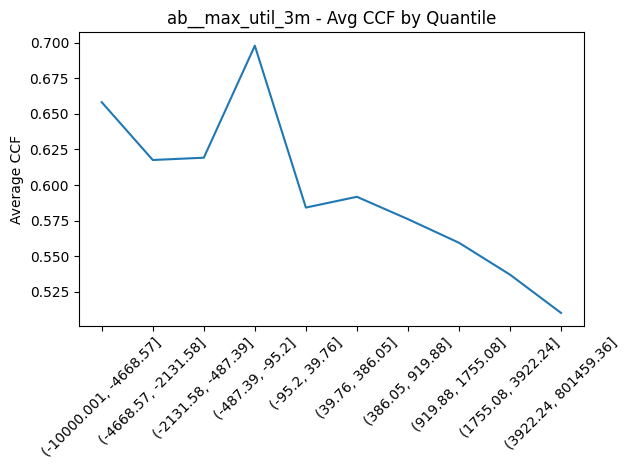


Feature: ab__max_bal_change_3m
Pearson Corr:  -0.0133
Spearman Corr: 0.0016

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-220232.40099999998, -1660.56]",0.585039,0.847505,1458
"(-1660.56, -664.798]",0.553836,0.785850,1458
"(-664.798, -254.83]",0.577194,0.906580,1458
"(-254.83, -72.014]",0.585513,0.980160,1458
"(-72.014, -6.49]",0.654916,1.000000,1458
"(-6.49, 8.152]",0.639514,1.000000,1458
"(8.152, 129.726]",0.603706,0.981185,1458
"(129.726, 413.232]",0.575850,0.880020,1458
"(413.232, 1237.288]",0.590271,0.893135,1458


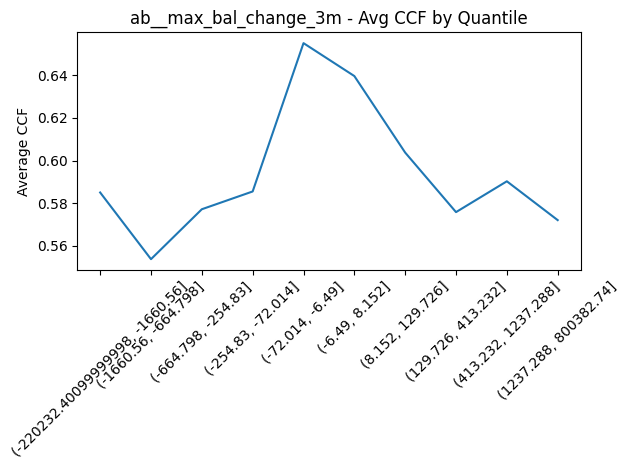


Feature: ab__std_util_3m
Pearson Corr:  -0.0385
Spearman Corr: -0.1356

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 7.947]",0.664438,1.000000,1513
"(7.947, 40.597]",0.679007,1.000000,1512
"(40.597, 90.536]",0.643559,1.000000,1512
"(90.536, 158.778]",0.611374,0.999550,1512
"(158.778, 248.43]",0.584951,0.944070,1512
"(248.43, 371.137]",0.586295,0.900390,1512
"(371.137, 547.288]",0.555313,0.816465,1512
"(547.288, 833.063]",0.539902,0.731665,1512
"(833.063, 1483.041]",0.542136,0.715025,1512


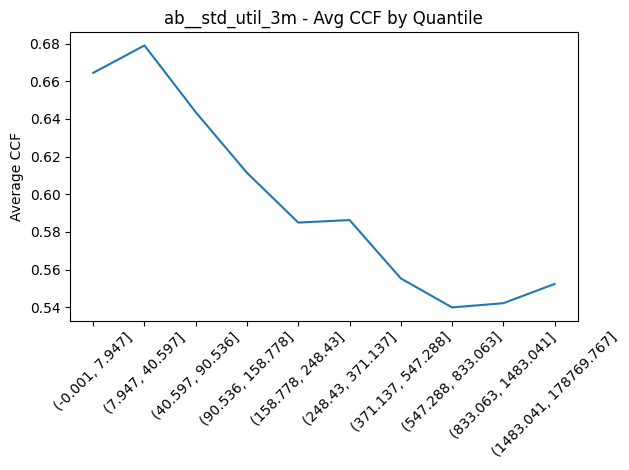


Feature: ab__std_bal_change_3m
Pearson Corr:  -0.0051
Spearman Corr: -0.0047

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-51962.731, -344.514]",0.573289,0.83083,1458
"(-344.514, -132.31]",0.563947,0.82505,1457
"(-132.31, -50.155]",0.575951,0.92508,1457
"(-50.155, -8.97]",0.605975,1.00000,1458
"(-8.97, 7.41e-15]",0.640272,1.00000,1457
"(7.41e-15, 15.402]",0.647457,1.00000,1457
"(15.402, 59.921]",0.593484,0.94304,1458
"(59.921, 149.674]",0.574026,0.87906,1457
"(149.674, 389.577]",0.585382,0.87383,1457


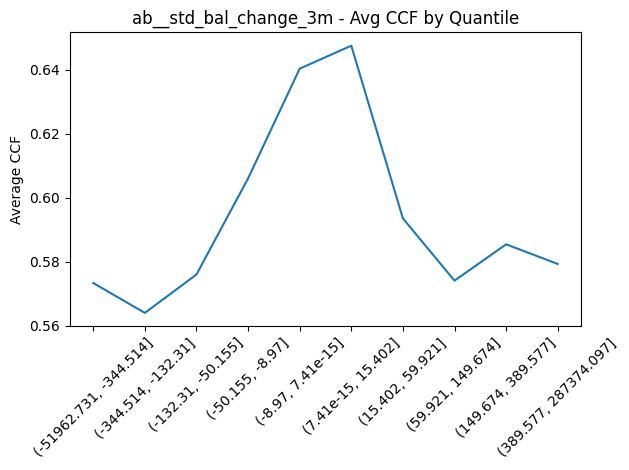


Feature: ab__bal_changed_3m
Pearson Corr:  0.0599
Spearman Corr: 0.0616

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


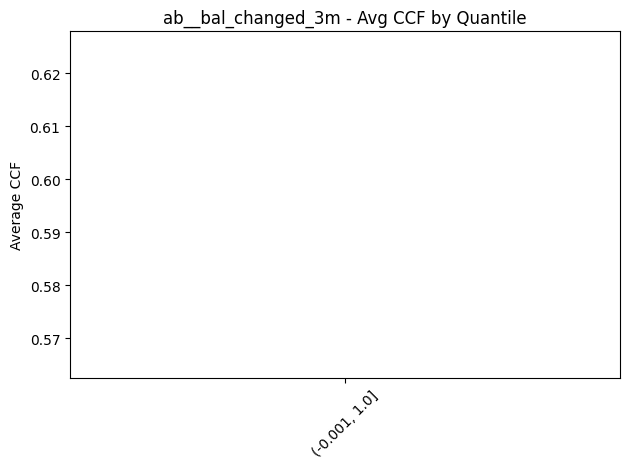


Feature: ab__bal_change_freq_3m
Pearson Corr:  -0.1006
Spearman Corr: -0.1375

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 2.0]",0.668860,1.00000,1933
"(2.0, 7.0]",0.648939,1.00000,1310
"(7.0, 15.0]",0.660445,1.00000,1407
"(15.0, 25.0]",0.611888,1.00000,1557
"(25.0, 35.0]",0.611279,0.98188,1435
"(35.0, 46.0]",0.558369,0.81714,1603
"(46.0, 56.0]",0.543227,0.74976,1502
"(56.0, 66.0]",0.555150,0.78090,1524
"(66.0, 76.0]",0.534696,0.69524,1487


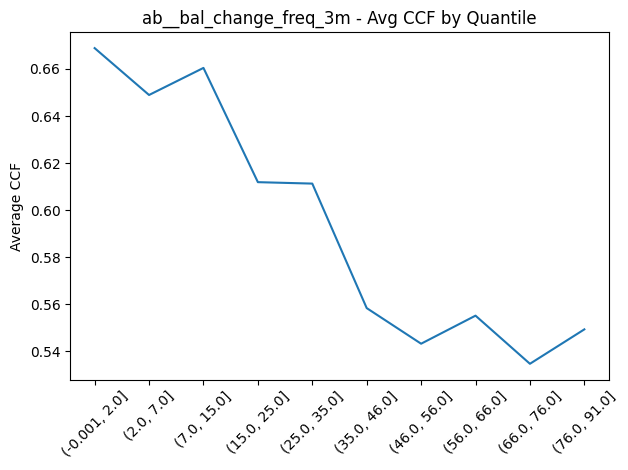


Feature: ab__mean_abs_change_6m
Pearson Corr:  -0.0618
Spearman Corr: -0.1505

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.701]",0.667942,1.000000,1513
"(0.701, 5.973]",0.687873,1.000000,1512
"(5.973, 16.759]",0.648691,1.000000,1512
"(16.759, 33.227]",0.604415,0.997990,1512
"(33.227, 54.04]",0.586696,0.918445,1512
"(54.04, 79.961]",0.599472,0.954710,1512
"(79.961, 112.583]",0.564382,0.820735,1512
"(112.583, 161.173]",0.547158,0.759180,1512
"(161.173, 254.91]",0.530370,0.669620,1512


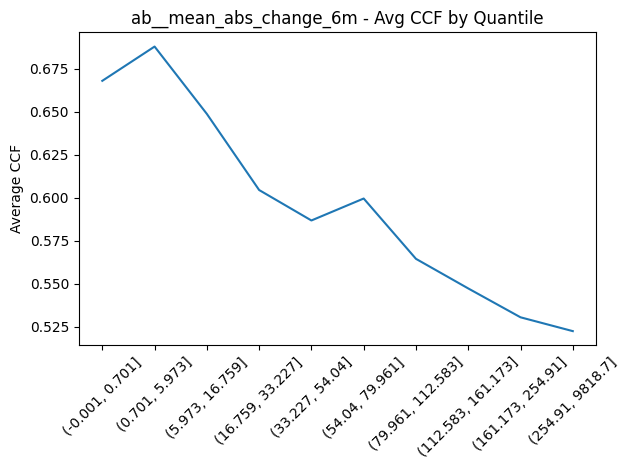


Feature: ab__std_abs_change_6m
Pearson Corr:  -0.0462
Spearman Corr: -0.1408

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 4.91]",0.669739,1.000000,1510
"(4.91, 27.999]",0.685883,1.000000,1509
"(27.999, 60.183]",0.642011,1.000000,1509
"(60.183, 103.81]",0.602661,0.986580,1509
"(103.81, 155.953]",0.586830,0.934010,1509
"(155.953, 221.354]",0.579648,0.903460,1509
"(221.354, 304.097]",0.564880,0.836100,1509
"(304.097, 432.609]",0.554502,0.793370,1509
"(432.609, 704.925]",0.545113,0.738600,1509


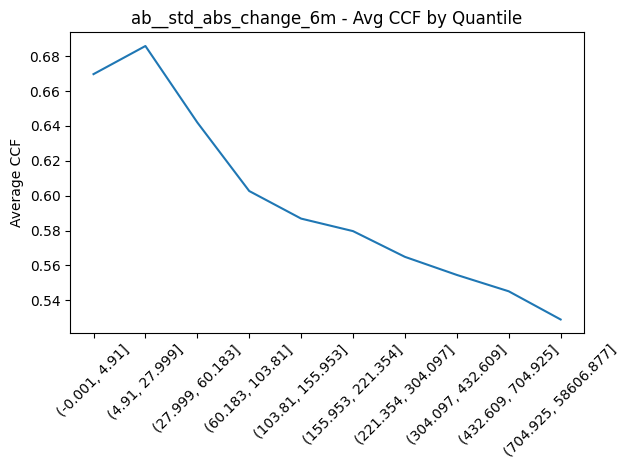


Feature: ab__max_one_day_drop_6m
Pearson Corr:  0.0303
Spearman Corr: 0.1230

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-456364.001, -3300.6]",0.548495,0.725850,1513
"(-3300.6, -1888.85]",0.560268,0.792010,1512
"(-1888.85, -1277.86]",0.554422,0.794460,1512
"(-1277.86, -971.79]",0.555348,0.796475,1512
"(-971.79, -683.44]",0.562167,0.838580,1512
"(-683.44, -475.15]",0.597598,0.969120,1513
"(-475.15, -283.44]",0.604858,0.976520,1511
"(-283.44, -143.27]",0.657431,1.000000,1512
"(-143.27, -20.0]",0.665733,1.000000,1533


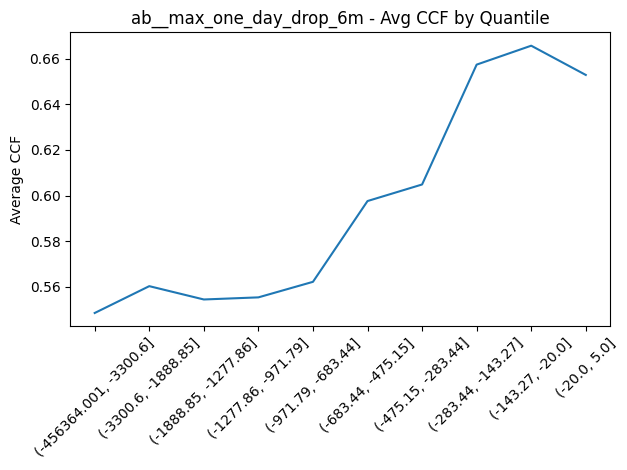


Feature: ab__inflow_spike_count_6m
Pearson Corr:  -0.0995
Spearman Corr: -0.1541

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.660159,1.000000,4726
"(1.0, 3.0]",0.649006,1.000000,1722
"(3.0, 5.0]",0.588247,0.935900,1433
"(5.0, 7.0]",0.549598,0.791445,1788
"(7.0, 9.0]",0.566096,0.825420,1413
"(9.0, 11.0]",0.548685,0.767025,1116
"(11.0, 16.0]",0.535894,0.701290,1650
"(16.0, 82.0]",0.508338,0.581220,1363


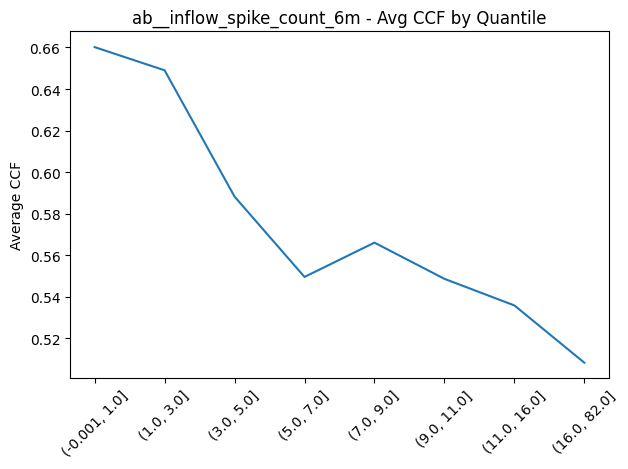


Feature: ab__days_down_6m
Pearson Corr:  -0.1036
Spearman Corr: -0.1379

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 2.0]",0.658033,1.000000,1750
"(2.0, 9.0]",0.677190,1.000000,1360
"(9.0, 21.0]",0.662378,1.000000,1540
"(21.0, 35.0]",0.609632,0.999040,1536
"(35.0, 50.0]",0.594105,0.940760,1477
"(50.0, 66.0]",0.576759,0.876515,1502
"(66.0, 82.0]",0.562803,0.850700,1509
"(82.0, 100.0]",0.528033,0.682360,1546
"(100.0, 120.0]",0.537152,0.714180,1487


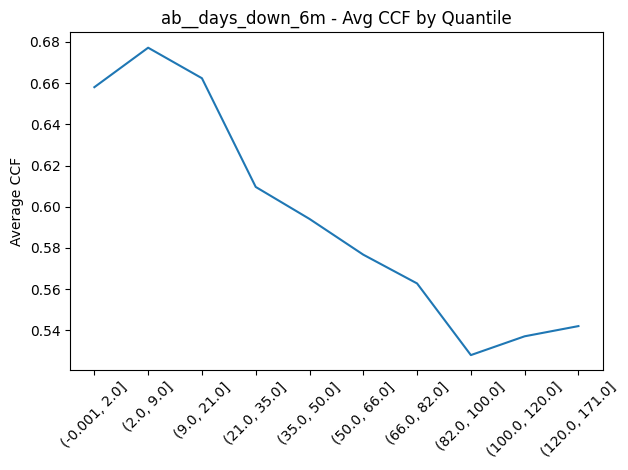


Feature: ab__near_zero_days_6m
Pearson Corr:  0.0159
Spearman Corr: -0.0400

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.608729,1.00000,7946
"(1.0, 5.0]",0.543106,0.72761,1386
"(5.0, 13.0]",0.531406,0.71569,1333
"(13.0, 35.0]",0.575589,0.84167,1509
"(35.0, 93.0]",0.624339,0.94414,1521
"(93.0, 181.0]",0.617549,0.97220,1516


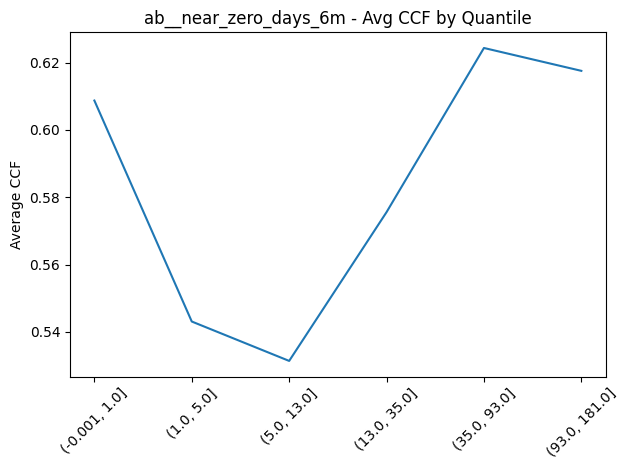

UNIVARIATE ANALYSIS - FEATURE GROUP: cb__


######## TARGET: t__ccf (Continuous) ########


Feature: cb__most_recent_score
Pearson Corr:  0.0042
Spearman Corr: 0.0028

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.522618,0.632315,1860
"(1.0, 2.0]",0.618279,0.996505,1938
"(2.0, 3.0]",0.613894,0.985770,1768
"(3.0, 4.0]",0.607665,0.976820,2133
"(4.0, 5.0]",0.613101,0.987000,1601
"(5.0, 7.0]",0.616951,0.984140,5062
"(7.0, 10.0]",0.465003,0.319680,798


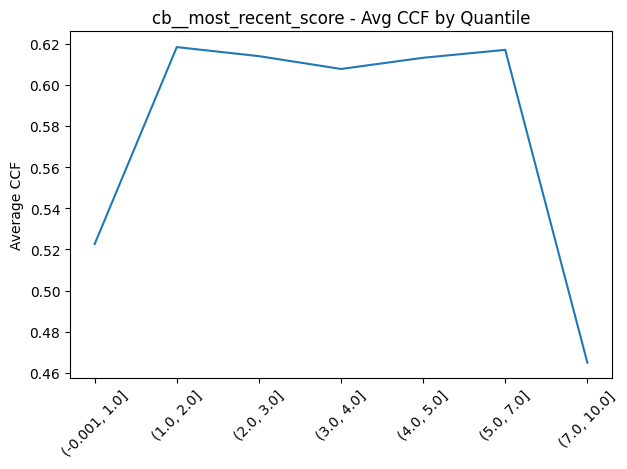


Feature: cb__worst_score
Pearson Corr:  0.0027
Spearman Corr: -0.0156

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 2.0]",0.526379,0.664565,1748
"(2.0, 4.0]",0.608494,0.976710,2509
"(4.0, 5.0]",0.616267,0.990745,1346
"(5.0, 6.0]",0.600419,0.955900,1033
"(6.0, 7.0]",0.636309,1.000000,6510
"(7.0, 9.0]",0.487242,0.507610,1048
"(9.0, 10.0]",0.494730,0.515705,966


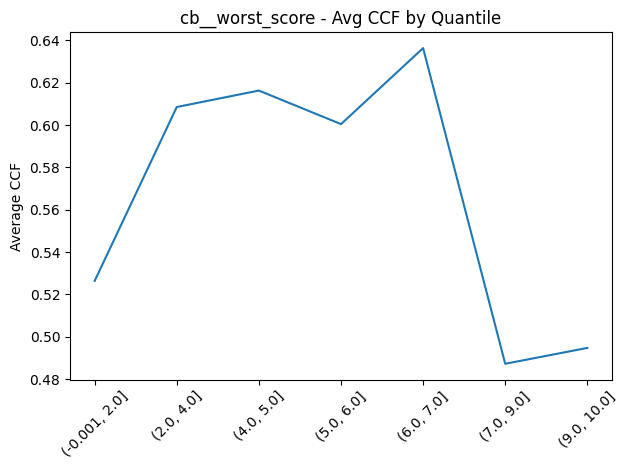

UNIVARIATE ANALYSIS - FEATURE GROUP: sd__


######## TARGET: t__ccf (Continuous) ########


Feature: sd__age
Pearson Corr:  -0.0896
Spearman Corr: -0.0970

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(17.999, 23.0]",0.661856,1.000000,1811
"(23.0, 25.0]",0.649311,1.000000,1358
"(25.0, 27.0]",0.612432,0.979245,1490
"(27.0, 30.0]",0.617464,0.990590,2014
"(30.0, 32.0]",0.608821,0.987920,1219
"(32.0, 35.0]",0.602242,0.957285,1600
"(35.0, 38.0]",0.553542,0.823240,1316
"(38.0, 43.0]",0.568983,0.876000,1567
"(43.0, 50.0]",0.522254,0.644045,1326


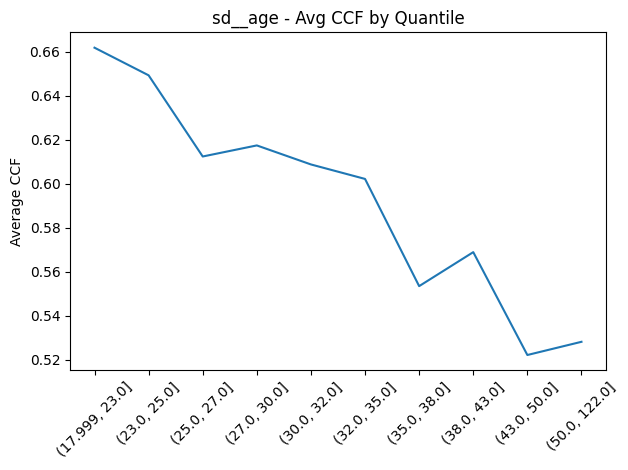


Feature: sd__age_since_first_kyc
Pearson Corr:  -0.0234
Spearman Corr: -0.0056

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(0.999, 176.0]",0.637859,0.996645,1506
"(176.0, 412.0]",0.579259,0.913570,1506
"(412.0, 625.1]",0.595268,0.923535,1500
"(625.1, 837.8]",0.578098,0.856480,1503
"(837.8, 1060.0]",0.588879,0.948420,1514
"(1060.0, 1279.0]",0.612165,0.969920,1500
"(1279.0, 1526.0]",0.629428,1.000000,1504
"(1526.0, 1804.6]",0.599787,0.969850,1497
"(1804.6, 2205.0]",0.588505,0.937535,1506


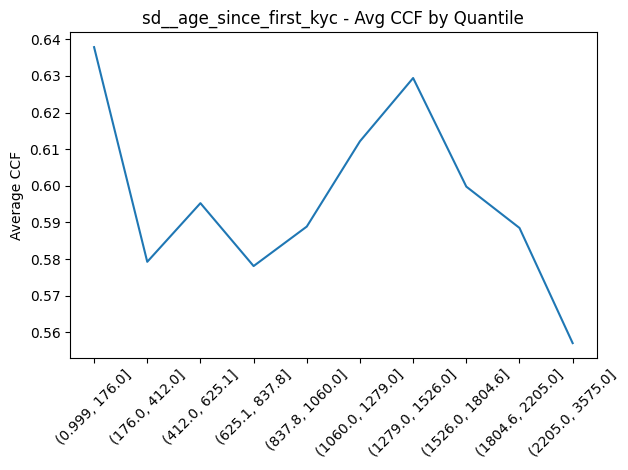


Feature: sd__age_since_last_kyc
Pearson Corr:  -0.0287
Spearman Corr: -0.0113

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(0.999, 158.7]",0.642460,0.999980,1504
"(158.7, 363.4]",0.579571,0.904100,1504
"(363.4, 570.0]",0.583894,0.908900,1510
"(570.0, 776.8]",0.589813,0.895840,1497
"(776.8, 985.5]",0.585673,0.924370,1504
"(985.5, 1208.0]",0.620842,0.983580,1510
"(1208.0, 1444.0]",0.623250,0.994575,1498
"(1444.0, 1727.0]",0.602607,0.980190,1508
"(1727.0, 2124.3]",0.598122,0.972630,1499


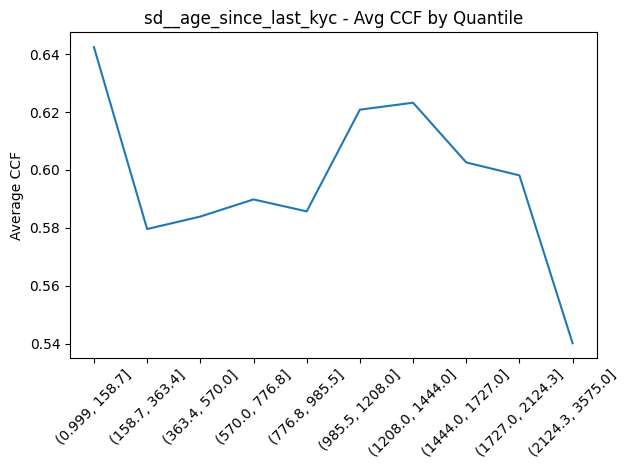


Feature: sd__membership_product
Pearson Corr:  -0.0223
Spearman Corr: -0.0270

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.608916,0.984035,7676
"(1.0, 2.0]",0.597619,0.930790,1693
"(2.0, 4.0]",0.584074,0.928180,2457
"(4.0, 5.0]",0.568018,0.831790,1663
"(5.0, 8.0]",0.589175,0.898040,1490


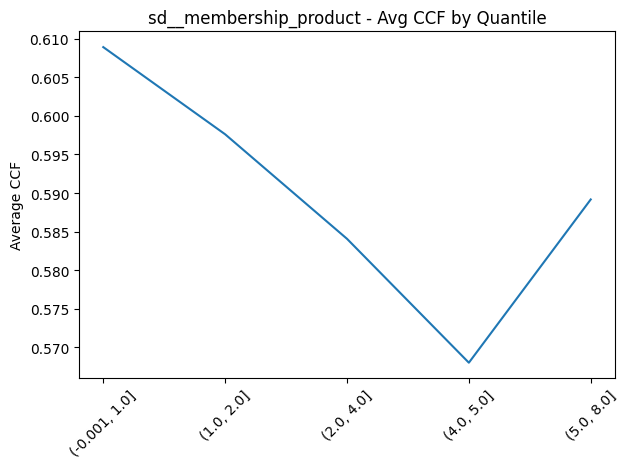


Feature: sd__max_daily_logins_6m
Pearson Corr:  0.0157
Spearman Corr: -0.0157

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(0.999, 3.0]",0.611578,1.000000,2321
"(3.0, 4.0]",0.558624,0.852690,1074
"(4.0, 5.0]",0.591195,0.924070,1194
"(5.0, 6.0]",0.560936,0.801170,1161
"(6.0, 8.0]",0.575720,0.873435,2146
"(8.0, 9.0]",0.573091,0.817310,851
"(9.0, 11.0]",0.590544,0.905060,1442
"(11.0, 14.0]",0.584852,0.893085,1454
"(14.0, 20.0]",0.602097,0.953395,1416


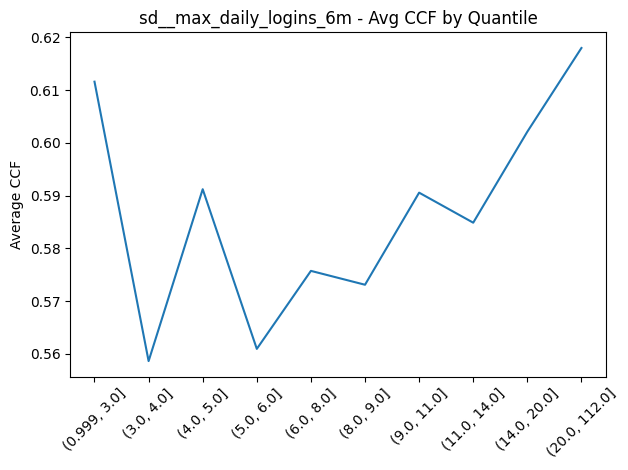


Feature: sd__max_daily_logins_12m
Pearson Corr:  0.0138
Spearman Corr: -0.0115

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(0.999, 3.0]",0.622192,1.000000,1530
"(3.0, 5.0]",0.571347,0.906900,1807
"(5.0, 7.0]",0.574016,0.859860,2089
"(7.0, 8.0]",0.569950,0.846860,1050
"(8.0, 9.0]",0.579310,0.868220,948
"(9.0, 11.0]",0.590992,0.909440,1677
"(11.0, 13.0]",0.586618,0.911075,1306
"(13.0, 16.0]",0.596502,0.931600,1337
"(16.0, 22.0]",0.591852,0.908145,1434


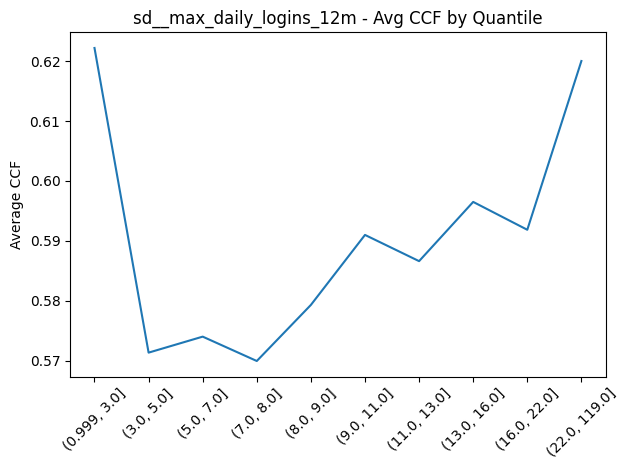

UNIVARIATE ANALYSIS - FEATURE GROUP: ep__


######## TARGET: t__ccf (Continuous) ########


Feature: ep__cc_tbil_balance
Pearson Corr:  0.0125
Spearman Corr: 0.0069

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 158.25]",0.592245,0.94458,13690
"(158.25, 25750.0]",0.621048,0.93618,1521


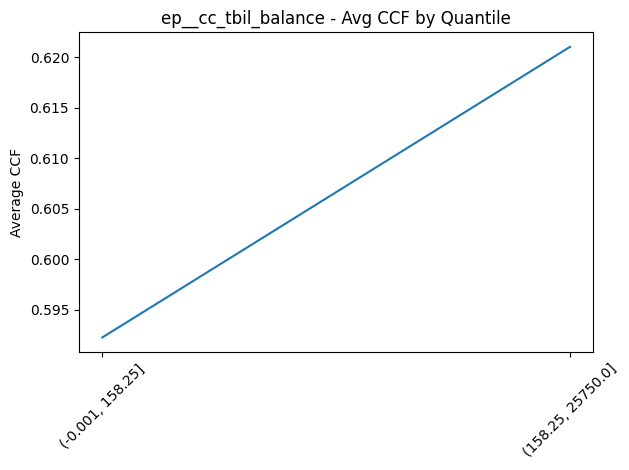

UNIVARIATE ANALYSIS - FEATURE GROUP: mv__


######## TARGET: t__ccf (Continuous) ########


Feature: mv__is_lisbon_v1
Pearson Corr:  -0.0141
Spearman Corr: 0.0209

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


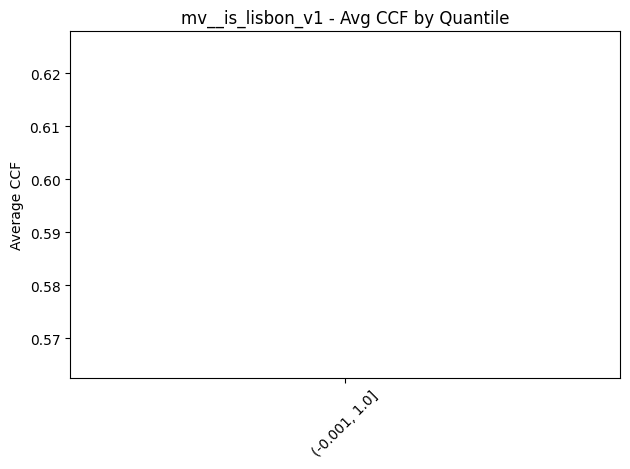


Feature: mv__is_lisbon_v2
Pearson Corr:  0.0080
Spearman Corr: -0.0061

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


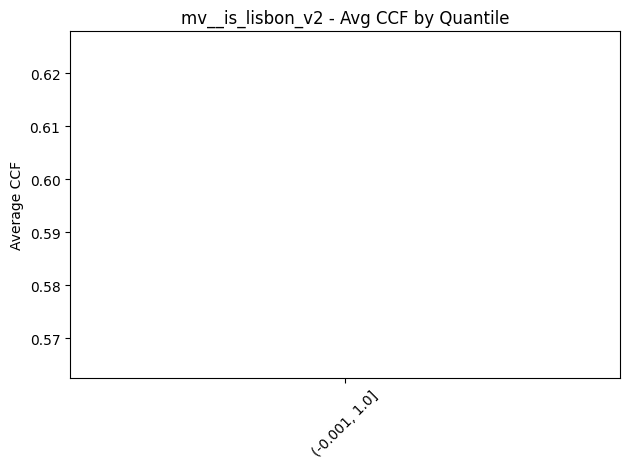


Feature: mv__is_lisbon_v3
Pearson Corr:  -0.0035
Spearman Corr: -0.0158

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


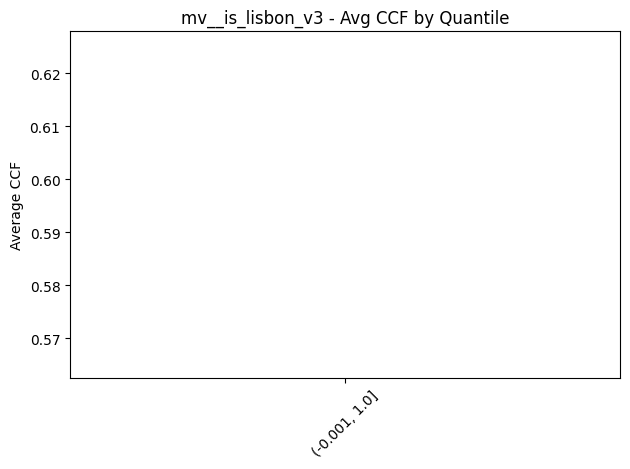


Feature: mv__is_lisbon_v4
Pearson Corr:  0.0029
Spearman Corr: -0.0060

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


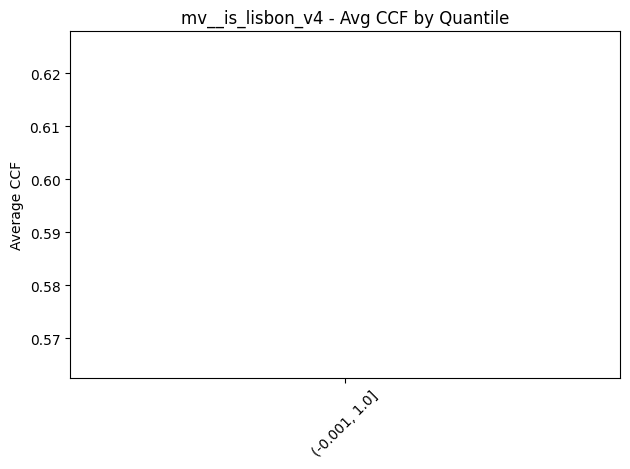


Feature: mv__is_porto_v1
Pearson Corr:  -0.0045
Spearman Corr: -0.0107

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


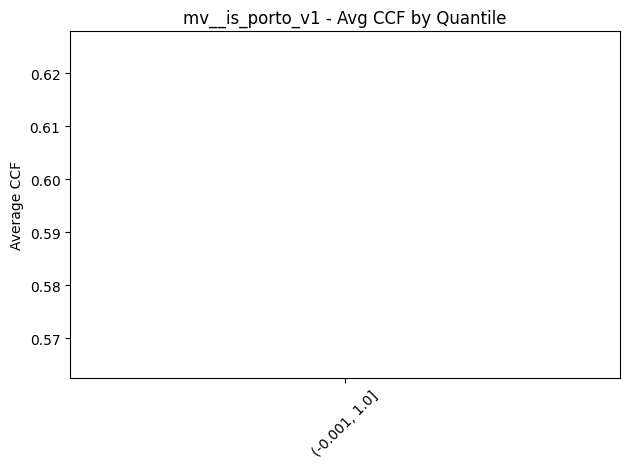


Feature: mv__is_porto_v2
Pearson Corr:  0.0164
Spearman Corr: -0.0104

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


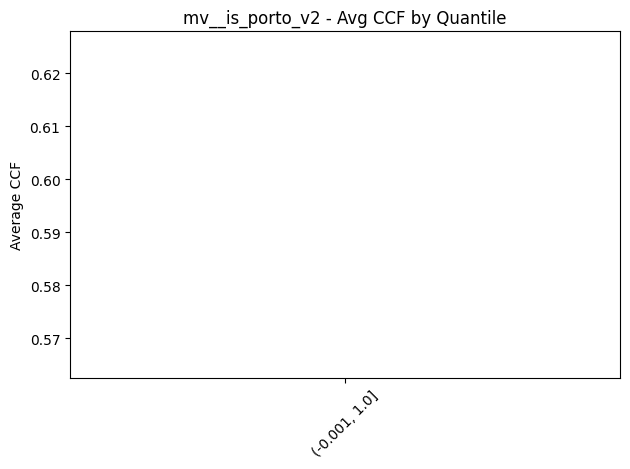

UNIVARIATE ANALYSIS - FEATURE GROUP: ob__


######## TARGET: t__ccf (Continuous) ########


Feature: ob__limit_ref
Pearson Corr:  -0.0234
Spearman Corr: -0.0403

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(0.699, 250.0]",0.629138,1.00000,3451
"(250.0, 500.0]",0.590676,0.93145,3306
"(500.0, 1000.0]",0.573381,0.88167,858
"(1000.0, 2900.0]",0.563958,0.89913,1512
"(2900.0, 4650.0]",0.600991,0.92954,1521
"(4650.0, 6000.0]",0.599924,0.95290,2345
"(6000.0, 8000.0]",0.590988,0.87845,941
"(8000.0, 12529.0]",0.553495,0.76597,1277


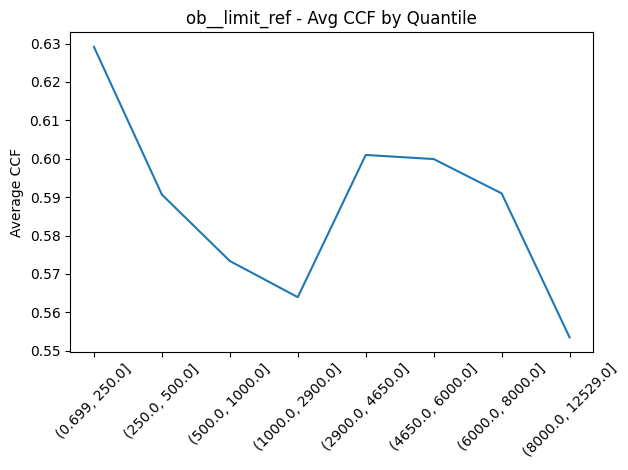


Feature: ob__balance_ref
Pearson Corr:  0.0321
Spearman Corr: 0.0818

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 185.22]",0.553363,0.76440,6085
"(185.22, 317.92]",0.662869,1.00000,1521
"(317.92, 574.35]",0.609666,1.00000,1521
"(574.35, 2019.38]",0.613502,0.98529,1521
"(2019.38, 4080.53]",0.619243,0.99859,1521
"(4080.53, 5993.29]",0.608991,0.99851,1521
"(5993.29, 10363.31]",0.623561,1.00000,1521


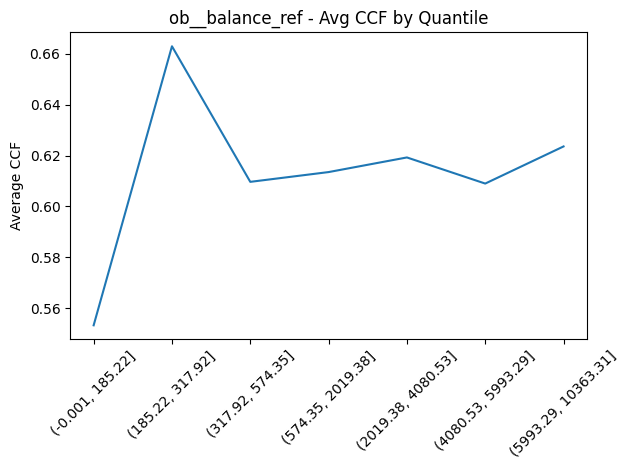


Feature: ob__avg_util_ref
Pearson Corr:  0.0581
Spearman Corr: 0.1136

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.274]",0.538942,0.70701,6085
"(0.274, 0.697]",0.626358,0.87512,1521
"(0.697, 0.89]",0.617273,0.94291,1521
"(0.89, 0.956]",0.719735,1.00000,1521
"(0.956, 0.99]",0.632591,1.00000,1521
"(0.99, 1.0]",0.616642,1.00000,1521
"(1.0, 32.275]",0.582925,1.00000,1521


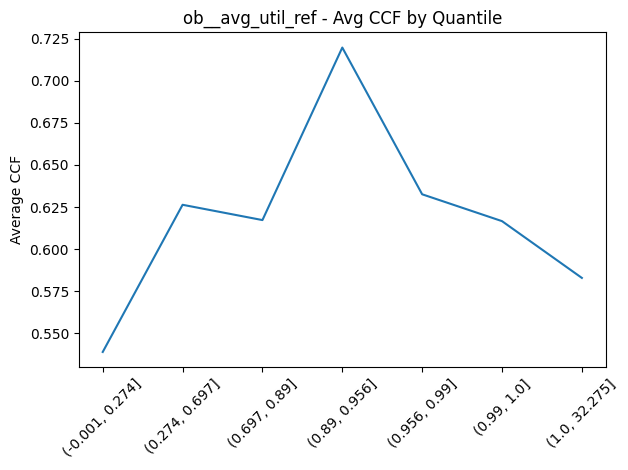


Feature: ob__open_limit_ref
Pearson Corr:  -0.0955
Spearman Corr: -0.1134

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.00038]",0.582816,1.000000,1523
"(0.00038, 0.00973]",0.617048,1.000000,1520
"(0.00973, 0.0444]",0.632591,1.000000,1521
"(0.0444, 0.11]",0.719735,1.000000,1521
"(0.11, 0.303]",0.617069,0.942780,1521
"(0.303, 0.726]",0.626562,0.875720,1521
"(0.726, 1.0]",0.538866,0.706505,6084


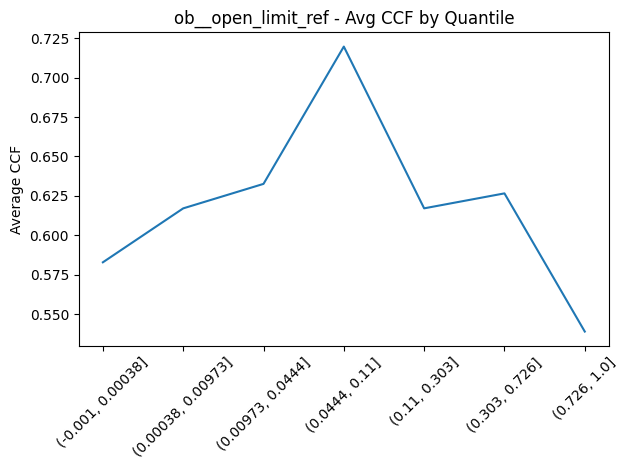


Feature: ob__avg_util_3m
Pearson Corr:  0.1208
Spearman Corr: 0.1623

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.0672]",0.523372,0.65951,4547
"(0.0672, 0.344]",0.549648,0.70113,1516
"(0.344, 0.615]",0.587488,0.85225,1516
"(0.615, 0.805]",0.603604,0.93577,1515
"(0.805, 0.908]",0.612199,1.00000,1516
"(0.908, 0.956]",0.689668,1.00000,1515
"(0.956, 0.989]",0.635161,1.00000,1516
"(0.989, 25.951]",0.717495,1.00000,1516


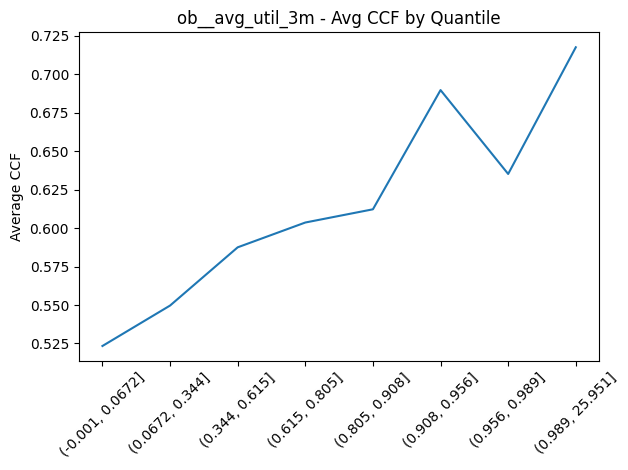


Feature: ob__avg_util_change_3m
Pearson Corr:  -0.0162
Spearman Corr: 0.0099

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-1.099, -0.137]",0.619390,0.911490,1122
"(-0.137, -0.0367]",0.584860,0.940300,1121
"(-0.0367, -0.00844]",0.634400,1.000000,1121
"(-0.00844, 0.0]",0.441298,0.076615,1436
"(0.0, 0.00833]",0.541292,0.872620,807
"(0.00833, 0.0224]",0.595830,1.000000,1121
"(0.0224, 0.0421]",0.707666,1.000000,1121
"(0.0421, 0.107]",0.605271,0.979630,1121
"(0.107, 0.252]",0.569229,0.843370,1121


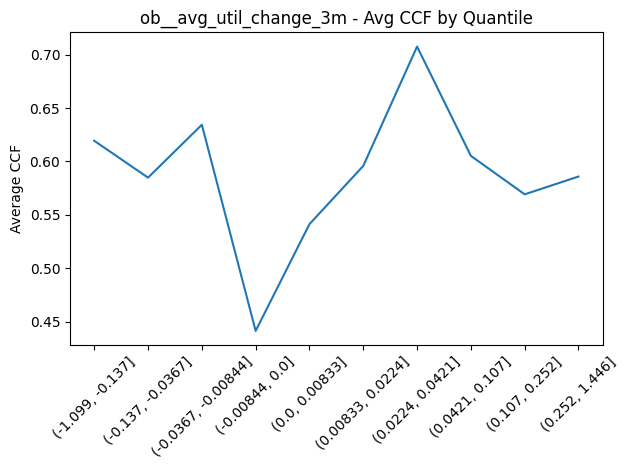


Feature: ob__max_util_3m
Pearson Corr:  0.0900
Spearman Corr: 0.0981

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.235]",0.526560,0.672480,4547
"(0.235, 0.799]",0.584236,0.771760,1516
"(0.799, 0.96]",0.710982,1.000000,1516
"(0.96, 0.997]",0.605273,0.985290,1515
"(0.997, 1.003]",0.597049,0.986255,1516
"(1.003, 1.018]",0.632551,1.000000,1515
"(1.018, 1.028]",0.641337,1.000000,1517
"(1.028, 28.574]",0.614217,1.000000,1515


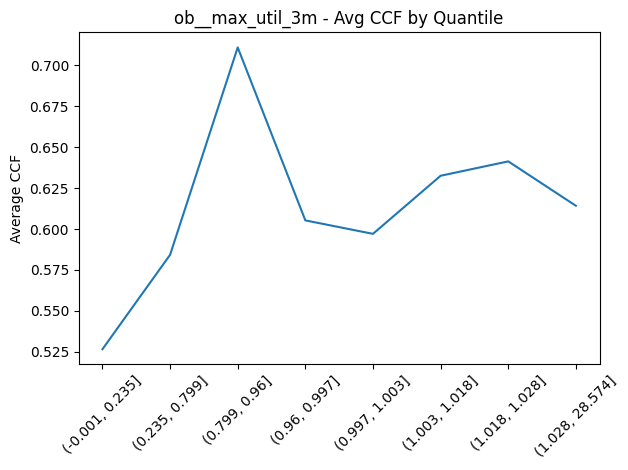


Feature: ob__max_util_change_3m
Pearson Corr:  -0.0055
Spearman Corr: -0.0016

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-7.708, -0.0608]",0.566114,0.763915,1122
"(-0.0608, -0.0222]",0.683905,1.000000,1121
"(-0.0222, -0.00539]",0.652598,1.000000,1121
"(-0.00539, 0.0]",0.457076,0.179825,1746
"(0.0, 0.0022]",0.523552,0.793370,497
"(0.0022, 0.0164]",0.542343,0.818180,1123
"(0.0164, 0.0271]",0.656668,1.000000,1119
"(0.0271, 0.0516]",0.640652,1.000000,1121
"(0.0516, 0.198]",0.586748,0.879060,1121


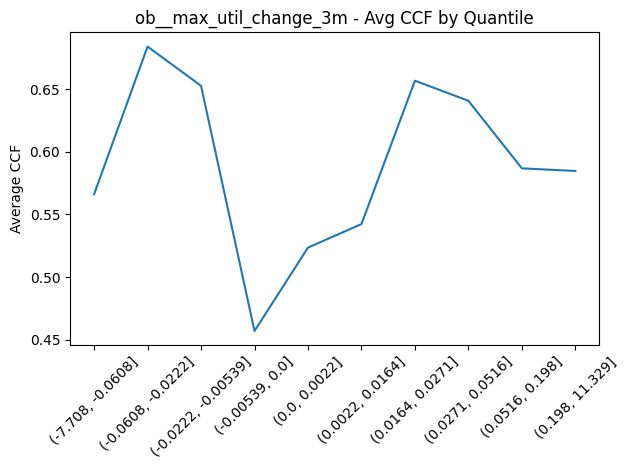


Feature: ob__std_util_3m
Pearson Corr:  -0.0050
Spearman Corr: -0.0258

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.00381]",0.345570,0.005400,1191
"(0.00381, 0.0127]",0.737231,1.000000,1191
"(0.0127, 0.0243]",0.699757,1.000000,1190
"(0.0243, 0.0452]",0.606957,1.000000,1191
"(0.0452, 0.0764]",0.594285,0.969855,1190
"(0.0764, 0.118]",0.582426,0.847790,1191
"(0.118, 0.18]",0.585227,0.882460,1190
"(0.18, 0.263]",0.568998,0.837610,1191
"(0.263, 0.352]",0.555555,0.812580,1190


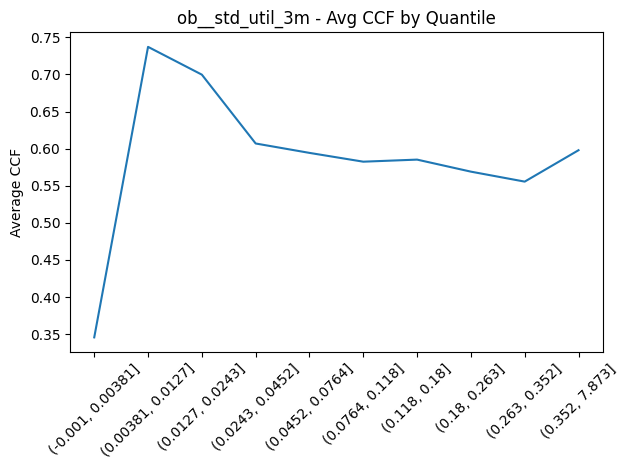


Feature: ob__std_util_change_3m
Pearson Corr:  0.0161
Spearman Corr: -0.0071

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-1.408, -0.107]",0.572352,0.912700,1117
"(-0.107, -0.0396]",0.594973,0.958045,1116
"(-0.0396, -0.0135]",0.577535,0.905855,1116
"(-0.0135, -0.00385]",0.639557,1.000000,1117
"(-0.00385, 0.0]",0.506719,0.557230,1582
"(0.0, 0.00245]",0.683062,1.000000,650
"(0.00245, 0.014]",0.575243,0.925390,1117
"(0.014, 0.0381]",0.599644,0.953410,1116
"(0.0381, 0.106]",0.582333,0.877650,1116


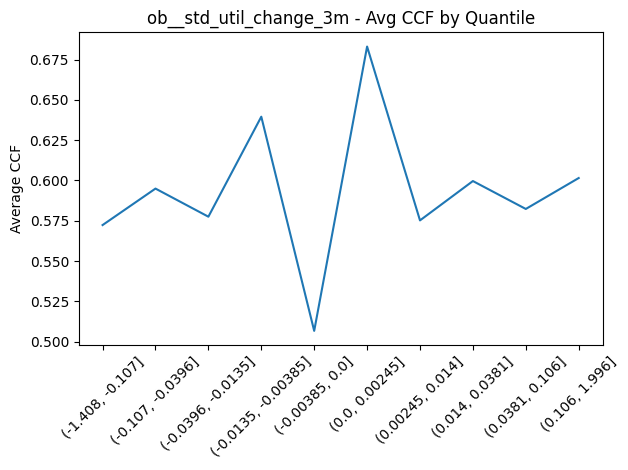


Feature: ob__util_slope_3m
Pearson Corr:  0.0196
Spearman Corr: 0.0215

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001000594, -1.79e-08]",0.597390,0.885720,1516
"(-1.79e-08, -2.85e-09]",0.626856,1.000000,1516
"(-2.85e-09, 0.0]",0.562558,0.831735,4474
"(0.0, 1e-10]",0.504508,0.696920,73
"(1e-10, 3.39e-09]",0.543329,0.818680,1515
"(3.39e-09, 7.57e-09]",0.714089,1.000000,1516
"(7.57e-09, 2.46e-08]",0.596314,0.952310,1515
"(2.46e-08, 7.39e-08]",0.579593,0.861200,1516
"(7.39e-08, 1.28e-05]",0.622853,0.999010,1516


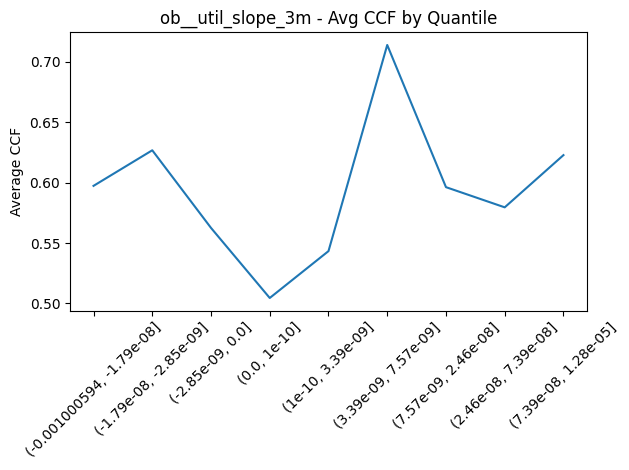


Feature: ob__util_range_3m
Pearson Corr:  -0.0226
Spearman Corr: -0.0139

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.0205]",0.551207,0.779995,4548
"(0.0205, 0.0586]",0.778799,1.000000,1515
"(0.0586, 0.161]",0.626877,1.000000,1516
"(0.161, 0.307]",0.603362,0.991620,1515
"(0.307, 0.529]",0.590453,0.901235,1516
"(0.529, 0.874]",0.546654,0.760550,1515
"(0.874, 1.0]",0.575731,0.867295,1516
"(1.0, 28.574]",0.589956,0.963760,1516


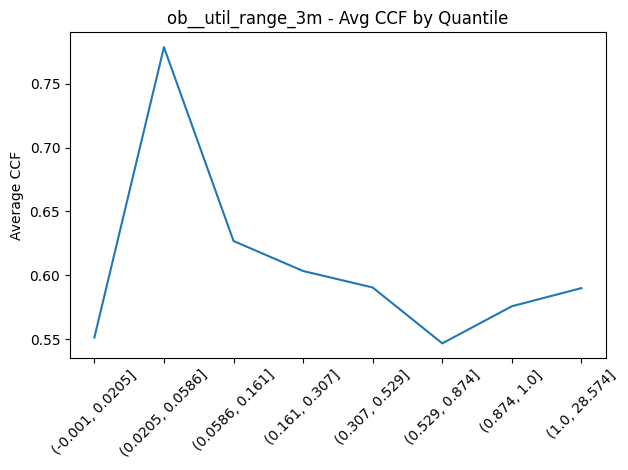


Feature: ob__num_od_entries_6m
Pearson Corr:  -0.0686
Spearman Corr: -0.0810

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.613321,0.992030,11446
"(1.0, 2.0]",0.569483,0.821750,972
"(2.0, 5.0]",0.545268,0.726215,1542
"(5.0, 33.0]",0.510030,0.603010,1251


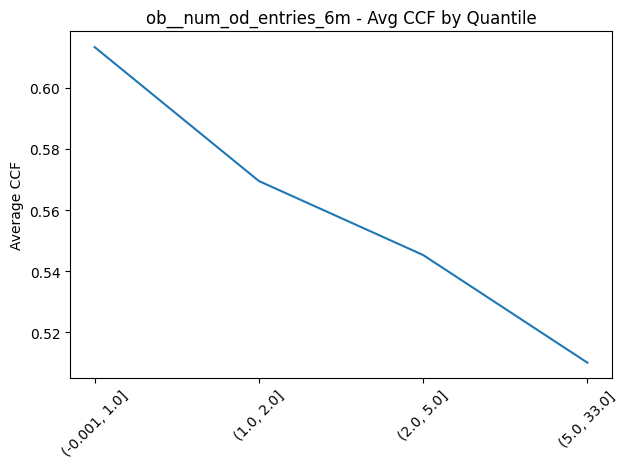


Feature: ob__num_od_exits_6m
Pearson Corr:  -0.0680
Spearman Corr: -0.0856

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.612656,0.991710,11716
"(1.0, 2.0]",0.557142,0.793470,876
"(2.0, 5.0]",0.543892,0.711875,1434
"(5.0, 32.0]",0.511885,0.608510,1185


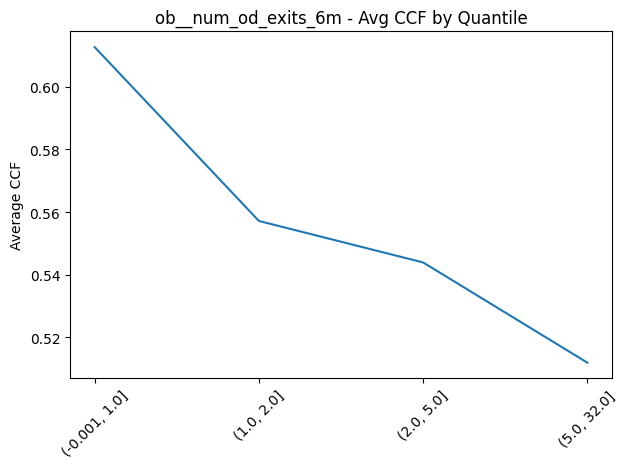


Feature: ob__overlimit_days_6m
Pearson Corr:  0.0729
Spearman Corr: 0.0888

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 6.0]",0.574878,0.843955,10690
"(6.0, 18.0]",0.602301,1.000000,1524
"(18.0, 39.0]",0.657593,1.000000,1530
"(39.0, 181.0]",0.670064,1.000000,1467


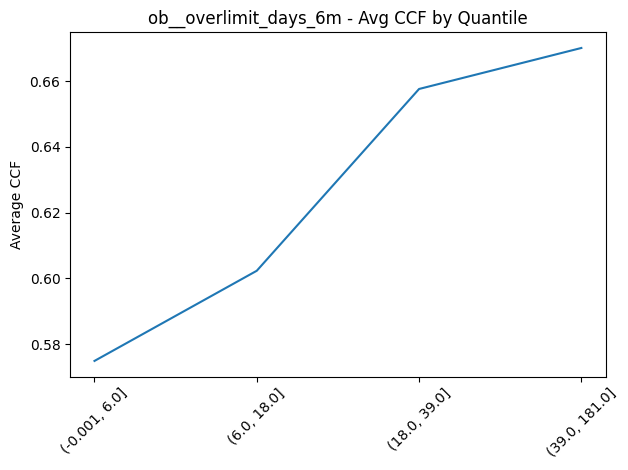


Feature: ob__full_repayment_events_6m
Pearson Corr:  -0.0680
Spearman Corr: -0.0856

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.612656,0.991710,11716
"(1.0, 2.0]",0.557142,0.793470,876
"(2.0, 5.0]",0.543892,0.711875,1434
"(5.0, 32.0]",0.511885,0.608510,1185


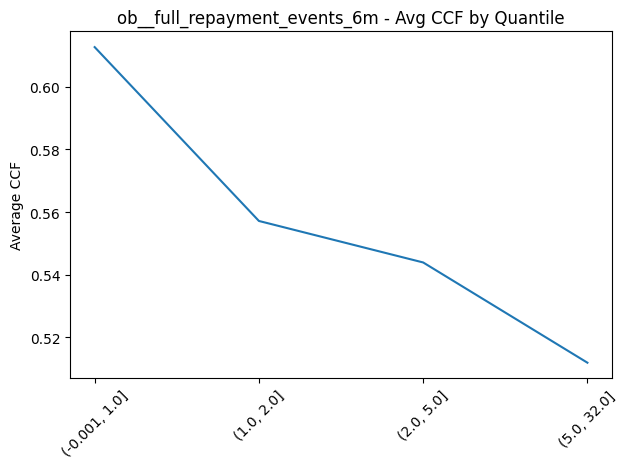


Feature: ob__max_consecutive_od_days_since_creation_ratio
Pearson Corr:  0.0316
Spearman Corr: 0.0237

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.603655,0.98251,12103


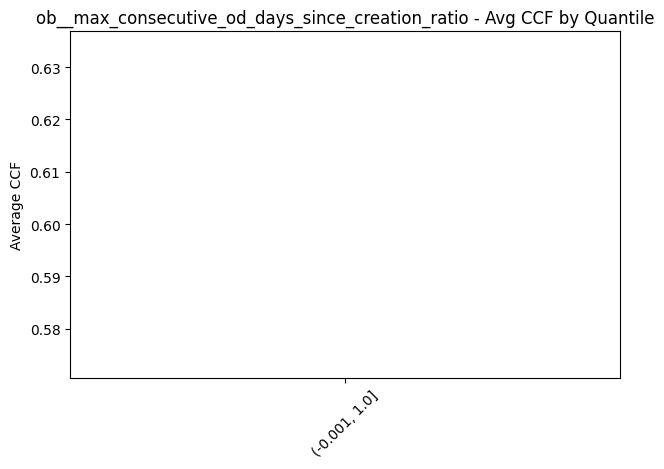


Feature: ob__od_draw_days_6m
Pearson Corr:  0.0869
Spearman Corr: 0.1323

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 16.0]",0.554318,0.792000,4581
"(16.0, 89.0]",0.529104,0.670320,1519
"(89.0, 147.0]",0.579612,0.841375,1524
"(147.0, 175.0]",0.577097,0.878450,1533
"(175.0, 181.0]",0.651040,1.000000,6054


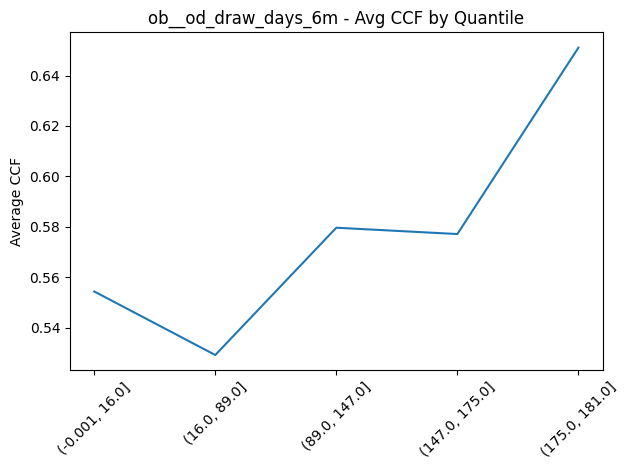


Feature: ob__od_enabled_zero_util_days_6m
Pearson Corr:  -0.1923
Spearman Corr: -0.1724

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.642045,1.000000,9167
"(1.0, 11.0]",0.603310,0.960000,1517
"(11.0, 36.0]",0.589726,0.935665,1504
"(36.0, 100.0]",0.547491,0.742335,1508
"(100.0, 181.0]",0.355806,0.013280,1515


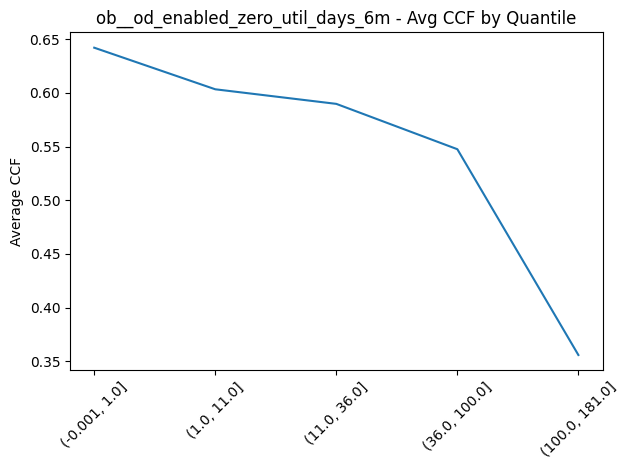


Feature: ob__technical_od_days_6m
Pearson Corr:  0.0226
Spearman Corr: 0.0157

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.590939,0.93590,13859
"(1.0, 180.0]",0.638041,0.98446,1352


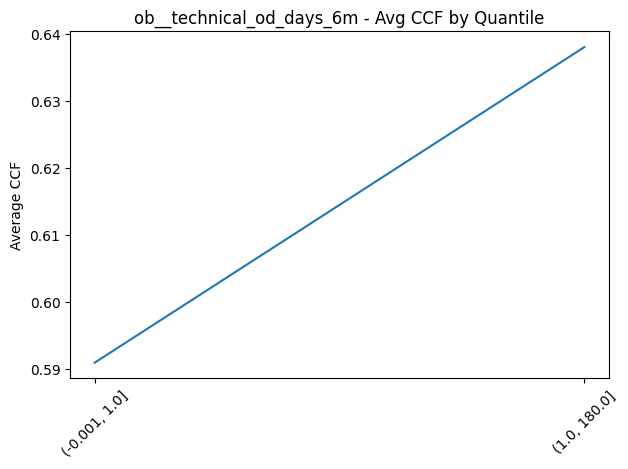


Feature: ob__technical_od_deep_days_6m
Pearson Corr:  0.0226
Spearman Corr: 0.0157

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.590939,0.93590,13859
"(1.0, 180.0]",0.638041,0.98446,1352


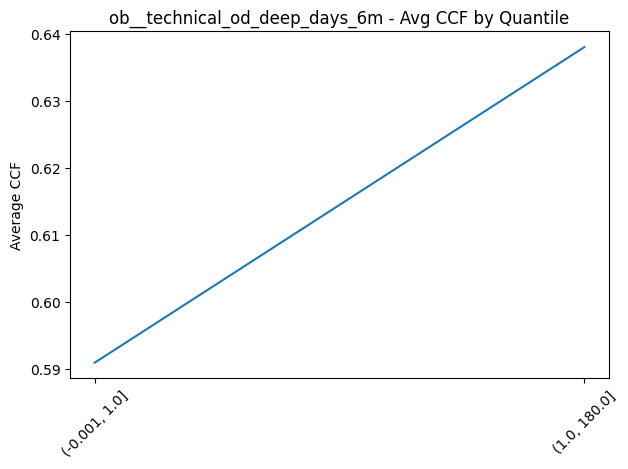


Feature: ob__avg_util_first_2m_since_creation
Pearson Corr:  0.0327
Spearman Corr: 0.0707

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.0325]",0.558529,0.79200,6049
"(0.0325, 0.131]",0.619603,0.97751,1512
"(0.131, 0.301]",0.640591,0.99971,1512
"(0.301, 0.493]",0.619353,1.00000,1512
"(0.493, 0.695]",0.628289,1.00000,1512
"(0.695, 0.883]",0.614456,1.00000,1512
"(0.883, 28.3]",0.608315,1.00000,1513


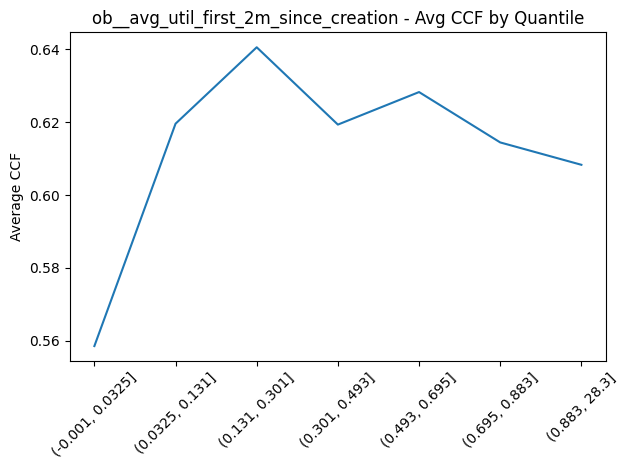


Feature: ob__avg_util_change_last2m_to_first2m
Pearson Corr:  0.1079
Spearman Corr: 0.1251

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-11.280999999999999, -0.048]",0.535540,0.712700,1513
"(-0.048, 0.0]",0.566371,0.829440,5101
"(0.0, 0.0467]",0.503262,0.505250,947
"(0.0467, 0.186]",0.602070,0.981130,1512
"(0.186, 0.359]",0.594559,0.958245,1512
"(0.359, 0.581]",0.646890,1.000000,1512
"(0.581, 0.82]",0.662981,1.000000,1512
"(0.82, 3.223]",0.696685,1.000000,1513


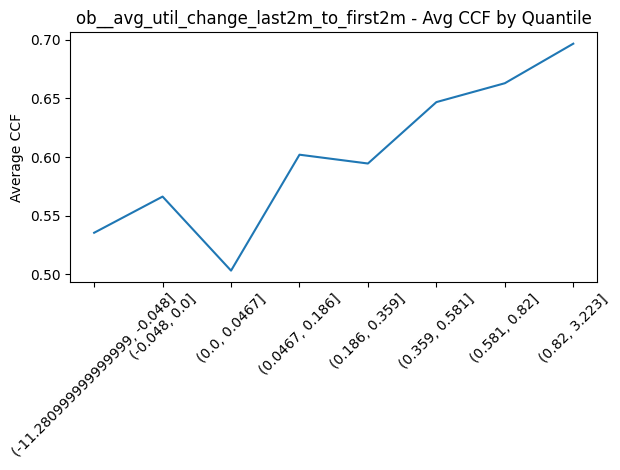


Feature: ob__avg_util_first2m_1y
Pearson Corr:  0.1765
Spearman Corr: 0.1713

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.0434]",0.433237,0.134515,1756
"(0.0434, 0.244]",0.568756,0.816865,878
"(0.244, 0.523]",0.586012,0.899050,878
"(0.523, 0.729]",0.603873,0.927730,878
"(0.729, 0.851]",0.649862,1.000000,877
"(0.851, 0.916]",0.697090,1.000000,878
"(0.916, 0.962]",0.620587,1.000000,878
"(0.962, 0.99]",0.647419,1.000000,878
"(0.99, 2.385]",0.694840,1.000000,878


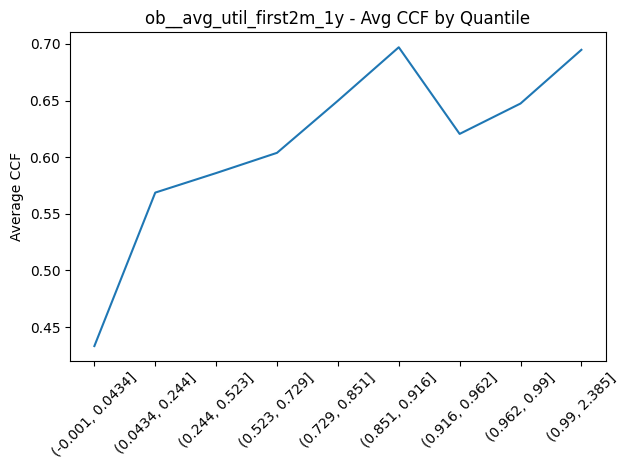


Feature: ob__avg_util_change_last2m_to_first2m_1y
Pearson Corr:  0.0576
Spearman Corr: 0.0915

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-1.2599999999999998, -0.165]",0.585788,0.830585,878
"(-0.165, -0.0371]",0.564989,0.810830,877
"(-0.0371, -0.001]",0.635734,1.000000,877
"(-0.001, 0.00711]",0.351518,0.000380,877
"(0.00711, 0.0336]",0.543927,0.870770,877
"(0.0336, 0.0733]",0.688123,1.000000,877
"(0.0733, 0.154]",0.653669,1.000000,877
"(0.154, 0.323]",0.624548,0.980640,877
"(0.323, 0.587]",0.632345,1.000000,877


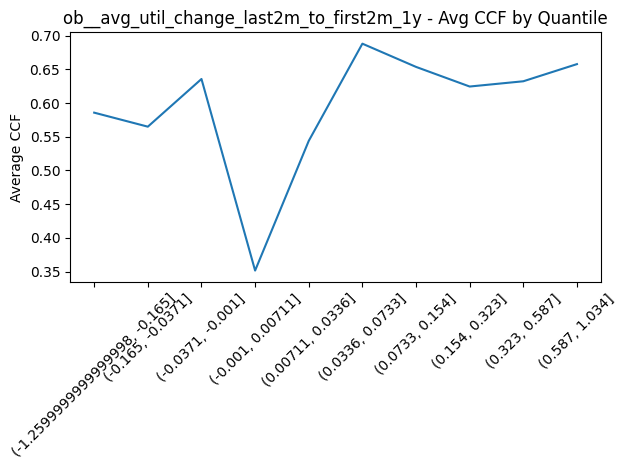


Feature: ob__max_consecutive_overlimit_days_since_creation_ratio
Pearson Corr:  0.0032
Spearman Corr: 0.0058

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.624508,1.0,7283


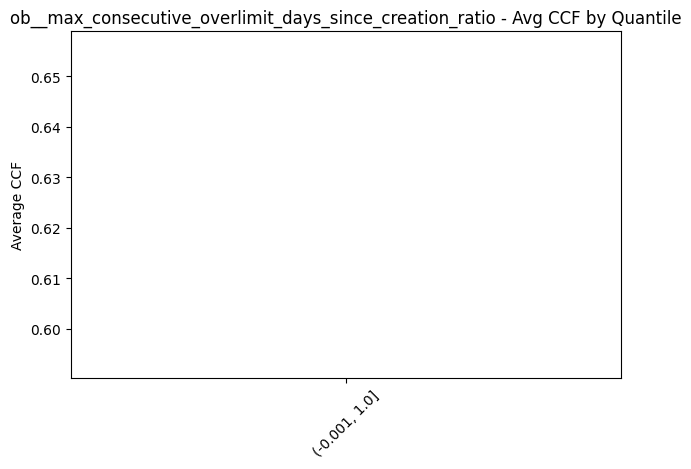


Feature: ob__partial_repayment_events_6m
Pearson Corr:  -0.0306
Spearman Corr: -0.0124

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.590399,0.914320,6582
"(1.0, 3.0]",0.651952,1.000000,1256
"(3.0, 7.0]",0.617477,1.000000,1668
"(7.0, 11.0]",0.607154,0.968835,1298
"(11.0, 17.0]",0.586892,0.904350,1441
"(17.0, 26.0]",0.578176,0.907330,1447
"(26.0, 120.0]",0.557754,0.843890,1519


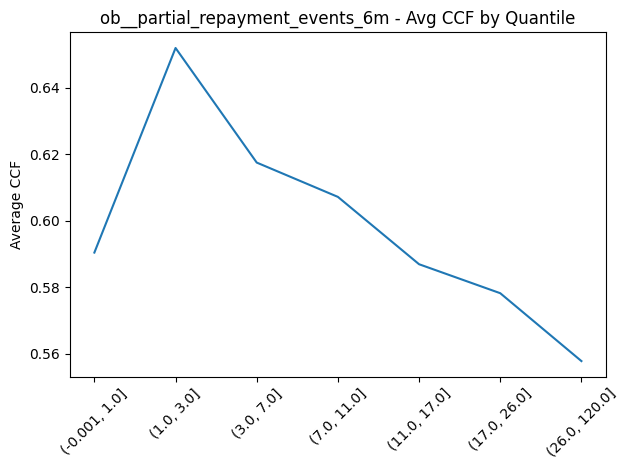


Feature: ob__full_repayment_change_3m_vs_prev_3m
Pearson Corr:  0.0016
Spearman Corr: -0.0043

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-11.001, -1.0]",0.546006,0.76519,2049
"(-1.0, 0.0]",0.612036,0.99144,10878
"(0.0, 1.0]",0.568983,0.81714,1213
"(1.0, 11.0]",0.546953,0.72156,1071


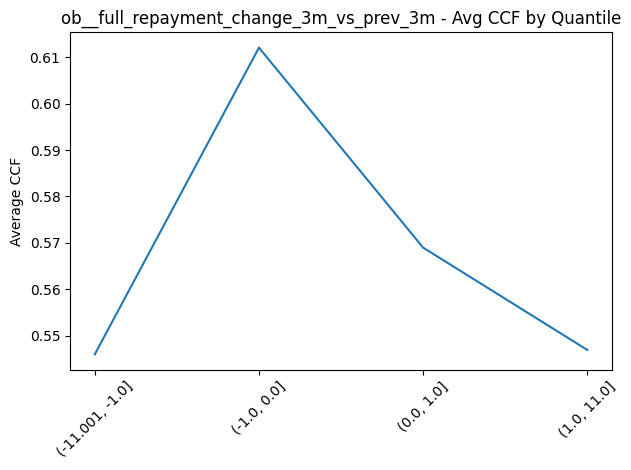


Feature: ob__util_last2m_to_first2m_ratio
Pearson Corr:  0.0022
Spearman Corr: 0.0816

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.66]",0.486657,0.45552,1053
"(0.66, 0.992]",0.565376,0.86248,1053
"(0.992, 1.0]",0.648772,0.99779,1169
"(1.0, 1.126]",0.621556,1.00000,937
"(1.126, 1.368]",0.623226,1.00000,1053
"(1.368, 1.801]",0.618202,1.00000,1052
"(1.801, 2.776]",0.649300,1.00000,1053
"(2.776, 5.547]",0.643190,1.00000,1053
"(5.547, 18.992]",0.666230,1.00000,1053


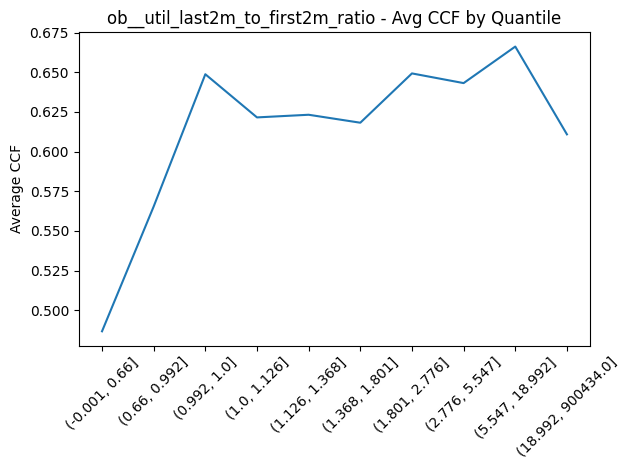


Feature: ob__util_last2m_to_first2m_1y_ratio
Pearson Corr:  -0.0214
Spearman Corr: 0.0512

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.586]",0.528161,0.65951,765
"(0.586, 0.922]",0.577766,0.82230,765
"(0.922, 0.986]",0.635842,1.00000,765
"(0.986, 1.011]",0.648277,1.00000,768
"(1.011, 1.051]",0.648973,1.00000,763
"(1.051, 1.105]",0.739319,1.00000,763
"(1.105, 1.264]",0.608656,1.00000,766
"(1.264, 1.858]",0.621226,1.00000,764
"(1.858, 4.977]",0.616980,0.99088,765


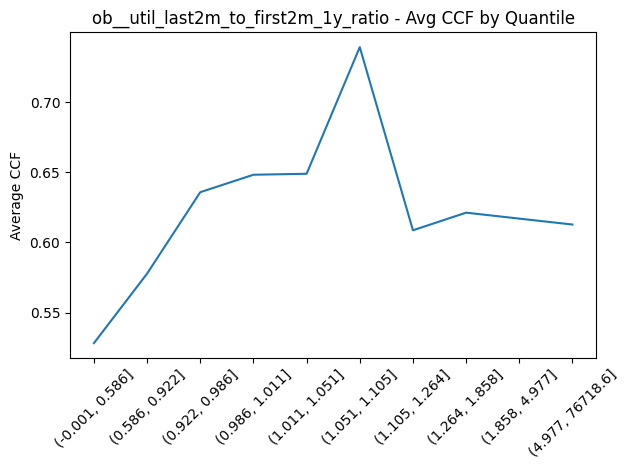


Feature: ob__max_to_avg_util_3m_ratio
Pearson Corr:  -0.0794
Spearman Corr: -0.1835

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(0.999, 1.013]",0.713677,1.000000,1176
"(1.013, 1.026]",0.771094,1.000000,1159
"(1.026, 1.042]",0.650048,1.000000,1162
"(1.042, 1.071]",0.605812,1.000000,1165
"(1.071, 1.128]",0.594044,0.979575,1168
"(1.128, 1.245]",0.578276,0.914730,1163
"(1.245, 1.476]",0.582583,0.884550,1165
"(1.476, 2.0]",0.583683,0.865510,1166
"(2.0, 3.758]",0.568474,0.784530,1165


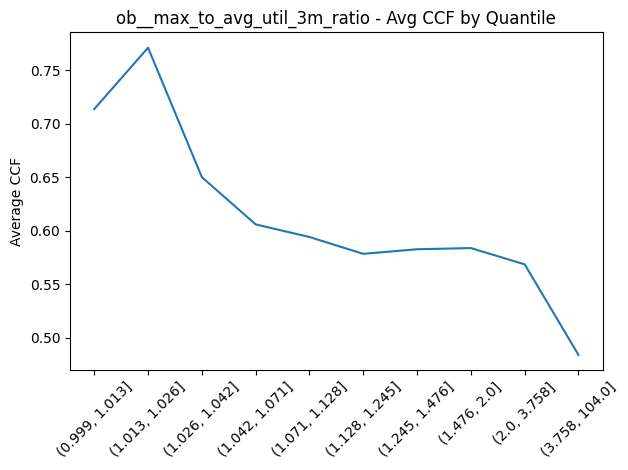

UNIVARIATE ANALYSIS - FEATURE GROUP: ul__


######## TARGET: t__ccf (Continuous) ########


Feature: ul__is_expat
Pearson Corr:  0.0760
Spearman Corr: 0.0811

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 1.0]",0.595126,0.94373,15211


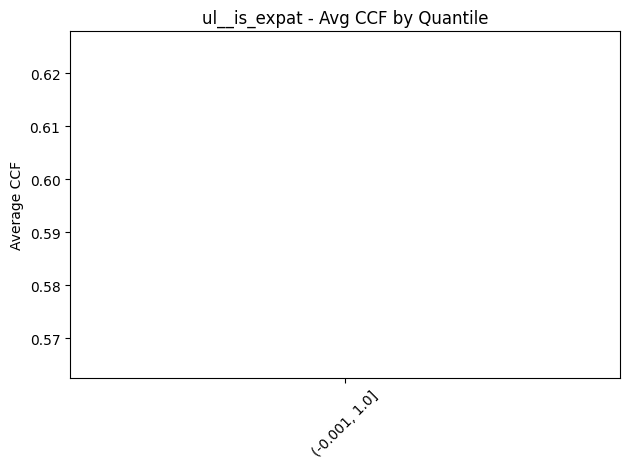

UNIVARIATE ANALYSIS - FEATURE GROUP: mix__


######## TARGET: t__ccf (Continuous) ########


Feature: mix__sd_od_history_to_kyc_ratio
Pearson Corr:  -0.0276
Spearman Corr: 0.0045

CCF by Quantile Bin:


/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_38608/2920813517.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])


,mean,median,count
bin,,,
"(-0.001, 0.00222]",0.606779,0.866110,1504
"(0.00222, 0.0323]",0.640645,0.967165,1506
"(0.0323, 0.254]",0.616330,0.981505,1502
"(0.254, 0.449]",0.573241,0.884840,1503
"(0.449, 0.596]",0.571406,0.876405,1504
"(0.596, 0.721]",0.591656,0.958280,1504
"(0.721, 0.829]",0.605906,0.995060,1503
"(0.829, 0.93]",0.619150,1.000000,1504
"(0.93, 0.999]",0.593767,0.998025,1504


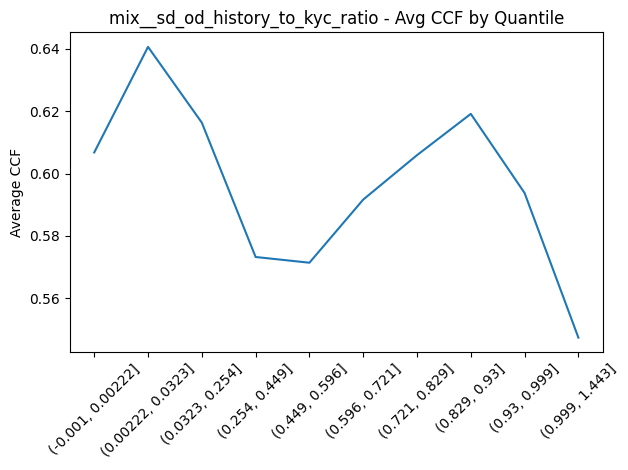

In [26]:
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
feature_groups = ['ab__', 'cb__', 'sd__', 'ep__',
                  'mv__', 'ob__', 'ul__', 'mix__']

continuous_target = 't__ccf'
binary_target = 't__is_drawn'

for prefix in feature_groups:

    print("=" * 100)
    print(f"UNIVARIATE ANALYSIS - FEATURE GROUP: {prefix}")
    print("=" * 100)

    group_cols = [col for col in features.columns if col.startswith(prefix)]

    if len(group_cols) == 0:
        print("No features found.\n")
        continue

    numeric_cols = features[group_cols].select_dtypes(include=np.number).columns
    categorical_cols = features[group_cols].select_dtypes(exclude=np.number).columns

    print("\n\n######## TARGET: t__ccf (Continuous) ########\n")

    for col in numeric_cols:

        df_temp = features[[col, continuous_target]].dropna()

        if df_temp.empty:
            continue

        # -------------------------------------------
        # Correlations
        # -------------------------------------------
        pearson_corr = df_temp[col].corr(df_temp[continuous_target], method='pearson')
        spearman_corr = df_temp[col].corr(df_temp[continuous_target], method='spearman')

        print(f"\nFeature: {col}")
        print(f"Pearson Corr:  {pearson_corr:.4f}")
        print(f"Spearman Corr: {spearman_corr:.4f}")

        # -------------------------------------------
        # Avg CCF by Quantile Bin
        # -------------------------------------------
        try:
            df_temp['bin'] = pd.qcut(df_temp[col], 10, duplicates='drop')

            grouped = df_temp.groupby('bin')[continuous_target].agg(['mean', 'median', 'count'])

            print("\nCCF by Quantile Bin:")
            display(grouped)

            plt.figure()
            plt.plot(grouped.index.astype(str), grouped['mean'].values)
            plt.xticks(rotation=45)
            plt.ylabel("Average CCF")
            plt.title(f"{col} - Avg CCF by Quantile")
            plt.tight_layout()
            plt.show()

        except:
            print("Binning failed (likely too few unique values).")


1. CATEGORICAL ANALYSIS (AVG CCF BAR CHARTS)

--- Feature Group: cb__ (Categorical) ---

[Categorical Feature]: cb__most_recent_score


,cb__most_recent_score,mean,median,count
0,A,0.498415,0.531390,479
1,B,0.531013,0.675590,1381
2,C,0.618279,0.996505,1938
3,D,0.613894,0.985770,1768
4,E,0.607665,0.976820,2133
5,F,0.613101,0.987000,1601
6,G,0.655417,1.000000,1159
7,M,0.605529,0.965120,3903
8,N,0.503090,0.522760,85
9,O,0.464136,0.309240,479


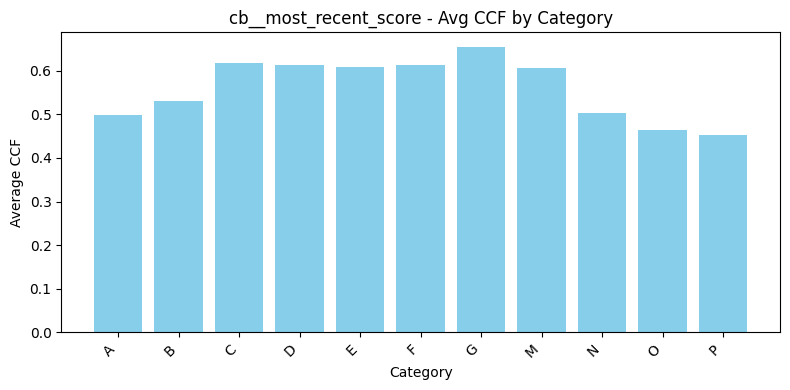


[Categorical Feature]: cb__worst_score


,cb__worst_score,mean,median,count
0,A,0.454400,0.174840,237
1,B,0.494580,0.441080,651
2,C,0.570286,0.921235,860
3,D,0.618809,0.988200,1039
4,E,0.601204,0.974790,1470
5,F,0.616267,0.990745,1346
6,G,0.600419,0.955900,1033
7,M,0.636309,1.000000,6510
8,N,0.524173,0.657340,138
9,O,0.481642,0.490955,910


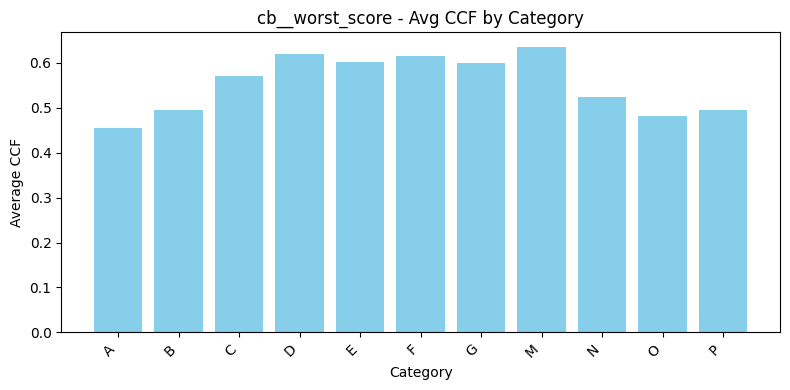


--- Feature Group: sd__ (Categorical) ---

[Categorical Feature]: sd__membership_product


,sd__membership_product,mean,median,count
0,BUSINESS_METAL,0.568096,0.835640,587
1,BUSINESS_SMART,0.606565,0.923235,588
2,BUSINESS_STANDARD,0.568018,0.831790,1663
3,BUSINESS_YOU,0.595992,0.949040,315
4,PERSONAL_FLEX,0.539464,0.716515,512
5,PERSONAL_METAL,0.596959,0.945095,1494
6,PERSONAL_SMART,0.597619,0.930790,1693
7,PERSONAL_STANDARD,0.613879,0.994250,7164
8,PERSONAL_YOU,0.564084,0.866620,963


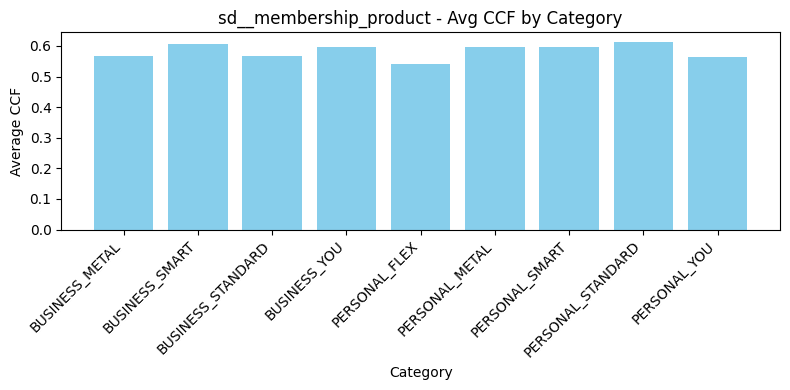

In [30]:
print("=" * 100)
print("1. CATEGORICAL ANALYSIS (AVG CCF BAR CHARTS)")
print("=" * 100)

for prefix in feature_groups:
    group_cols = [col for col in features.columns if col.startswith(prefix)]

    if not group_cols:
        continue

    # Select object/categorical columns before encoding converts them to numbers
    categorical_cols = features[group_cols].select_dtypes(
        exclude=np.number
    ).columns

    if len(categorical_cols) == 0:
        continue

    print(f"\n--- Feature Group: {prefix} (Categorical) ---")

    for col in categorical_cols:
        df_temp = features[[col, continuous_target]].dropna()

        if df_temp.empty:
            continue

        print(f"\n[Categorical Feature]: {col}")

        # Avg CCF by Category
        grouped = (
            df_temp.groupby(col, observed=False)[continuous_target]
            .agg(["mean", "median", "count"])
            .reset_index()
        )

        display(grouped)

        # Bar chart for categorical features
        plt.figure(figsize=(8, 4))
        plt.bar(
            grouped[col].astype(str),
            grouped["mean"],
            color="skyblue"
        )
        plt.xticks(rotation=45, ha="right")
        plt.xlabel("Category")
        plt.ylabel("Average CCF")
        plt.title(f"{col} - Avg CCF by Category")
        plt.tight_layout()
        plt.show()